# EDA for BDD dataset 

For this EDA, we will focus on metadata only (which comes from the labels) as we are short on time.  One can also add image level EDA, but it will require more resources and time. Hence we are focusing on train and validation set only. 

A single datapoint from BDD dataset has following data 

1. Image 
2. Weather
3. Time of the Day
4. Timestamp 
5. List of Bounding boxes in the image
6. Whether the bounding box was occluded/truncated or not 
7. `manualshape` and `manualattributes` for bbox # TODO know more about this.


### Class distribution for Object detection classes

There are 10 classes in BDD dataset for object detection task, and in the paper they have given following distribution for the classes 

![image.png](../../assets/image.png)


We can notice the long tailed distribution for the classes and `train` and `motor` classes are under-represented. Hence, if model is not trained properly, model can perform bad for these class instances. Need to handle this imbalance. 

In [40]:
import json
import pandas as pd 
import pathlib 
import matplotlib.pyplot as plt 
import numpy as np

In [11]:
LABELS_DATA_PATH = pathlib.Path("../../data/assignment_data_bdd/bdd100k_labels_release/bdd100k/labels")
TRAIN_LABELS_PATH = LABELS_DATA_PATH/"bdd100k_labels_images_train.json"
VAL_LABELS_PATH = LABELS_DATA_PATH/"bdd100k_labels_images_val.json"

In [ ]:
class BDDMetadata:

    def __init__(self, file_path:pathlib.Path):
        self.raw_data = json.load(open(file_path,'r'))
        self.build_dataframes()
    
    def build_dataframes(self):
        img_rows = []
        object_rows = []

        for img in self.raw_data:
            img_name = img.get("name")

            img_rows.append({
                "image": img_name,
                "weather": img.get("attributes", {}).get("weather"),
                "timeofday": img.get("attributes", {}).get("timeofday"),
                "scene": img.get("attributes", {}).get("scene"),
            })

            if "labels" not in img: # nno bbox case 
                continue

            for bbox in img["labels"]:
                if "box2d" not in bbox:
                    continue

                box = bbox["box2d"]

                width = box["x2"] - box["x1"]
                height = box["y2"] - box["y1"]

                object_rows.append({
                    "image": img_name,
                    "category": bbox.get("category"),
                    "x1": box["x1"],
                    "y1": box["y1"],
                    "x2": box["x2"],
                    "y2": box["y2"],
                    "width": width,
                    "height": height,
                    "area": width * height,
                    "aspect_ratio": width / (height),
                    "occluded": bbox.get("attributes", {}).get("occluded"),
                    "truncated": bbox.get("attributes", {}).get("truncated"),
                })
                
        self.images_df = pd.DataFrame(img_rows)
        self.bbox_df = pd.DataFrame(object_rows)

In [13]:
train_data = BDDMetadata(TRAIN_LABELS_PATH)
val_data = BDDMetadata(VAL_LABELS_PATH)

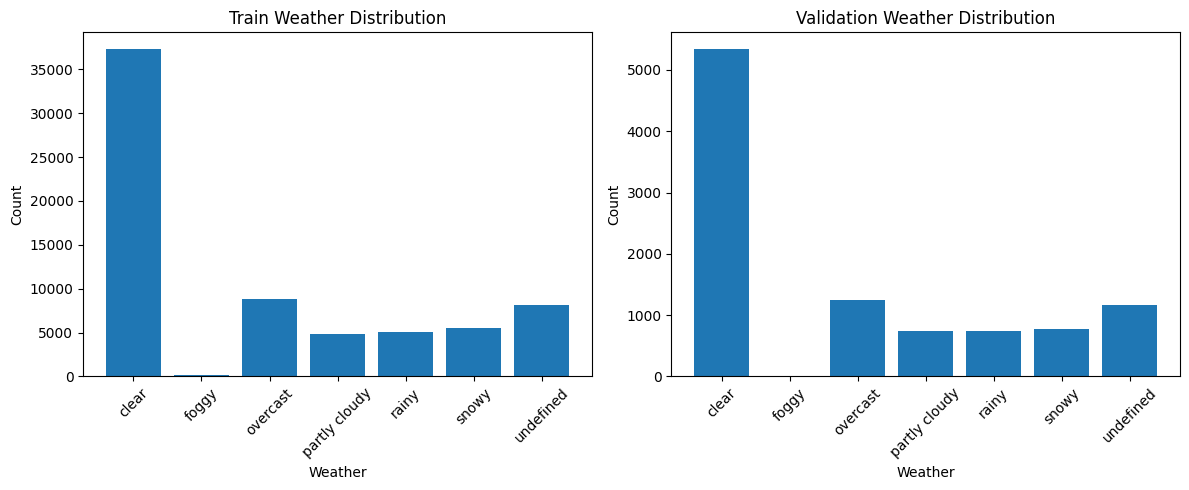

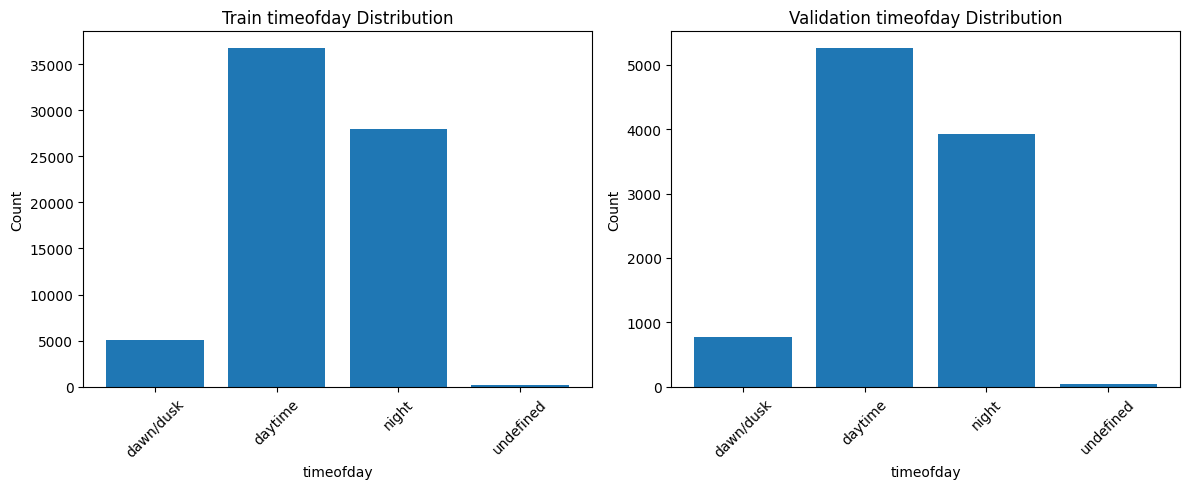

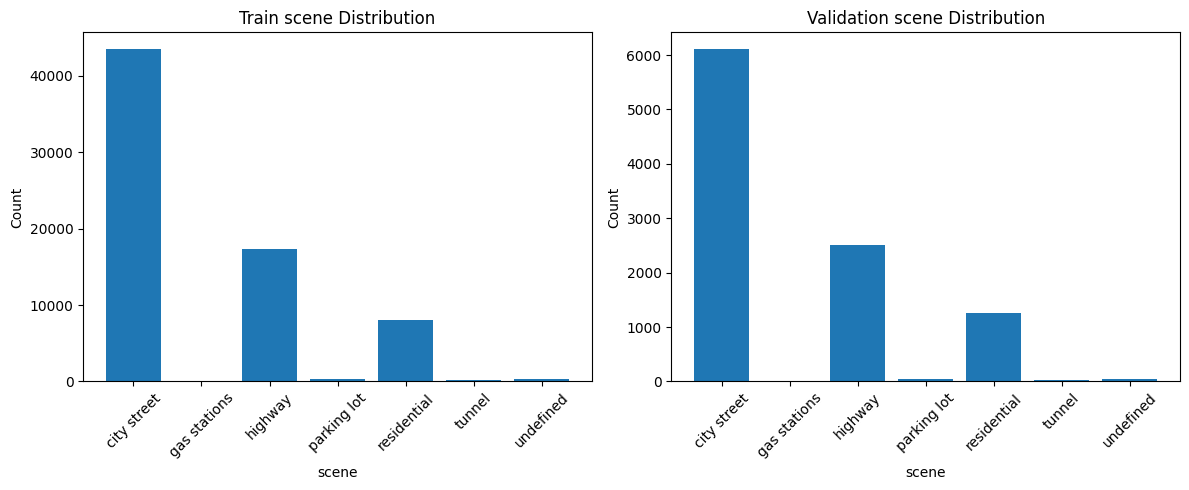

In [21]:

# Count weather distribution
train_counts = train_data.images_df['weather'].value_counts()
val_counts = val_data.images_df['weather'].value_counts()

# Align categories
all_weathers = sorted(set(train_counts.index).union(set(val_counts.index)))
train_counts = train_counts.reindex(all_weathers, fill_value=0)
val_counts = val_counts.reindex(all_weathers, fill_value=0)

# Create subplots (1 row, 2 columns)
plt.figure(figsize=(12, 5))

# ---- Train Plot ----
plt.subplot(1, 2, 1)
plt.bar(train_counts.index, train_counts.values)
plt.title('Train Weather Distribution')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=45)

# ---- Validation Plot ----
plt.subplot(1, 2, 2)
plt.bar(val_counts.index, val_counts.values)
plt.title('Validation Weather Distribution')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Count weather distribution
train_counts = train_data.images_df['timeofday'].value_counts()
val_counts = val_data.images_df['timeofday'].value_counts()

# Align categories
all_weathers = sorted(set(train_counts.index).union(set(val_counts.index)))
train_counts = train_counts.reindex(all_weathers, fill_value=0)
val_counts = val_counts.reindex(all_weathers, fill_value=0)

# Create subplots (1 row, 2 columns)
plt.figure(figsize=(12, 5))

# ---- Train Plot ----
plt.subplot(1, 2, 1)
plt.bar(train_counts.index, train_counts.values)
plt.title('Train timeofday Distribution')
plt.xlabel('timeofday')
plt.ylabel('Count')
plt.xticks(rotation=45)

# ---- Validation Plot ----
plt.subplot(1, 2, 2)
plt.bar(val_counts.index, val_counts.values)
plt.title('Validation timeofday Distribution')
plt.xlabel('timeofday')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



# Count weather distribution
train_counts = train_data.images_df['scene'].value_counts()
val_counts = val_data.images_df['scene'].value_counts()

# Align categories
all_weathers = sorted(set(train_counts.index).union(set(val_counts.index)))
train_counts = train_counts.reindex(all_weathers, fill_value=0)
val_counts = val_counts.reindex(all_weathers, fill_value=0)

# Create subplots (1 row, 2 columns)
plt.figure(figsize=(12, 5))

# ---- Train Plot ----
plt.subplot(1, 2, 1)
plt.bar(train_counts.index, train_counts.values)
plt.title('Train scene Distribution')
plt.xlabel('scene')
plt.ylabel('Count')
plt.xticks(rotation=45)

# ---- Validation Plot ----
plt.subplot(1, 2, 2)
plt.bar(val_counts.index, val_counts.values)
plt.title('Validation scene Distribution')
plt.xlabel('scene')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [22]:
# Overall distribution is same in train and validation which is good, but would be interesting to see if model behaves correctly in those images where we have very less samples

### Lets see if there any class which has significant number of occlusions or truncations

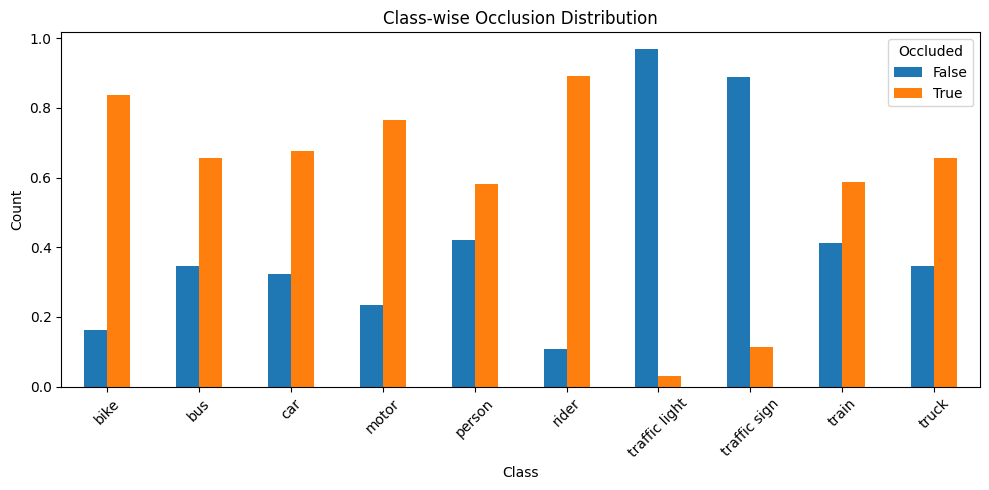

In [ ]:

# Count occlusion per class
occlusion_counts = (
    train_data.bbox_df
    .groupby(["category", "occluded"])
    .size()
    .unstack(fill_value=0)
)

# occlusion_counts.plot(kind="bar", figsize=(10, 5))
occlusion_percent = occlusion_counts.div(occlusion_counts.sum(axis=1), axis=0)
occlusion_percent.plot(kind="bar", figsize=(10, 5))

plt.title("Class-wise Occlusion Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Occluded")
plt.tight_layout()
plt.show()

### This indicates that in general we have high occlusion percentage in moving object classes like bike, bus etc. It might still be possible that there is sufficient portion of the image is visible for detection, but we need to be aware of this fact.  

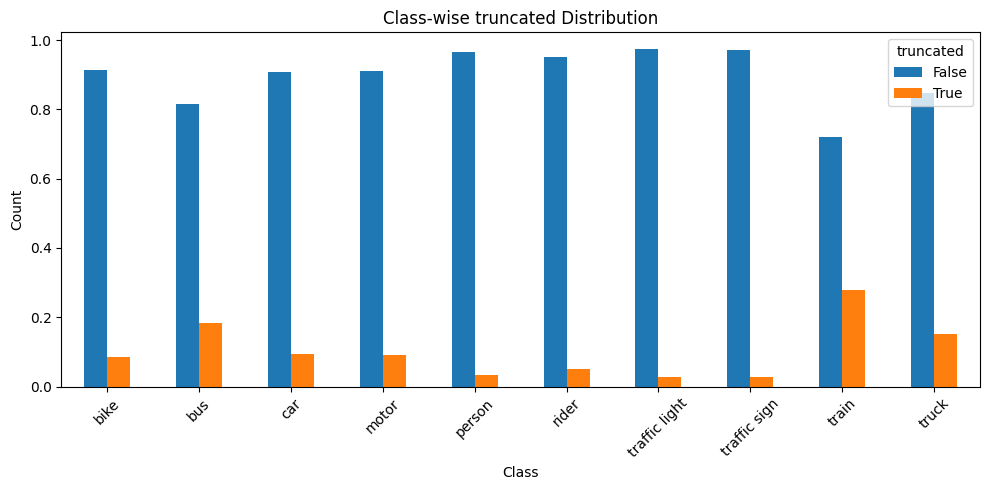

In [37]:

# Count occlusion per class
trunc_counts = (
    train_data.bbox_df
    .groupby(["category", "truncated"])
    .size()
    .unstack(fill_value=0)
)
trunc_pct = trunc_counts.div(trunc_counts.sum(axis=1), axis=0)
trunc_pct.plot(kind="bar", figsize=(10, 5))

plt.title("Class-wise truncated Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="truncated")
plt.tight_layout()
plt.show()

### would be nice to see model performances on these truncated cases

In [ ]:
# 

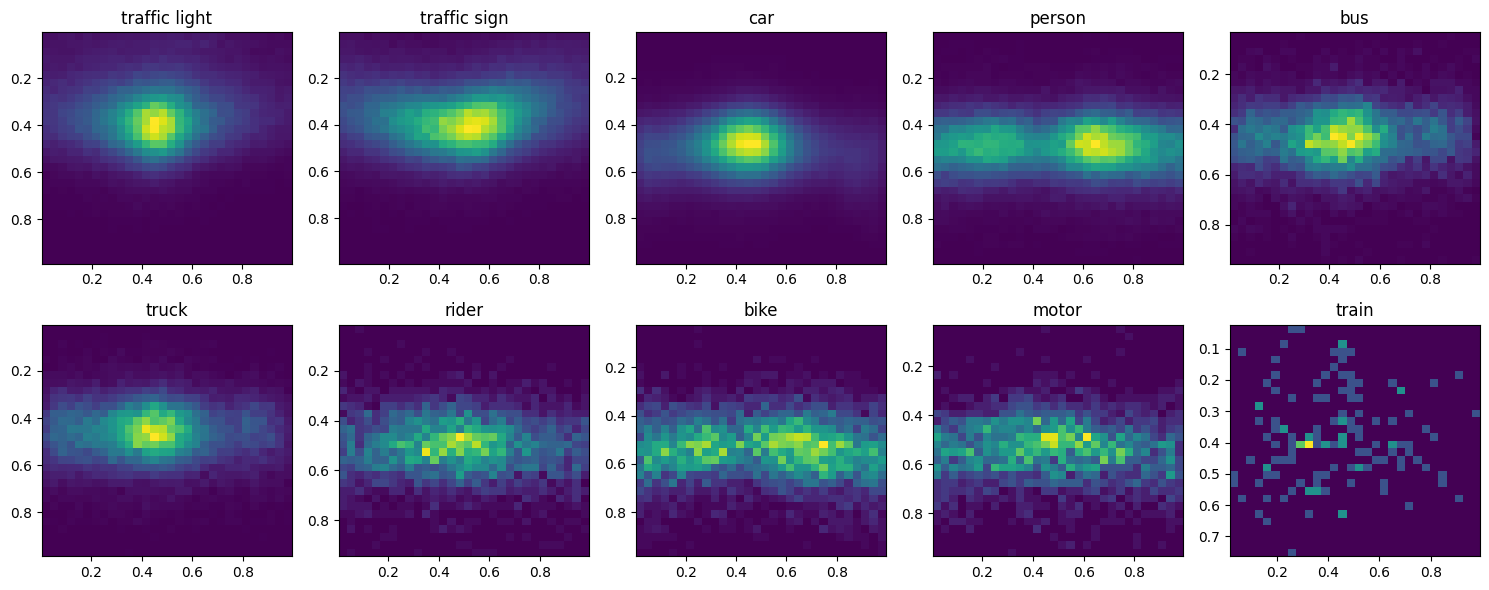

In [ ]:

# compute centers
train_data.bbox_df["center_x"] = (train_data.bbox_df["x1"] + train_data.bbox_df["x2"]) / 2
train_data.bbox_df["center_y"] = (train_data.bbox_df["y1"] + train_data.bbox_df["y2"]) / 2

# normalize (since all images are 1280x720)
train_data.bbox_df["center_x"] /= 1280
train_data.bbox_df["center_y"] /= 720

classes = train_data.bbox_df["category"].unique()



fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 10 classes
axes = axes.flatten()

for i, cls in enumerate(classes):
    subset = train_data.bbox_df[train_data.bbox_df["category"] == cls]

    axes[i].hist2d(
        subset["center_x"],
        subset["center_y"],
        bins=30
    )

    axes[i].invert_yaxis()
    axes[i].set_title(cls)

plt.tight_layout()
plt.show()

## We can see many classes are generally clustered together. It is possible that this kind of distribution might add a geometric bias in model. If a class appears outside of the cluster, it is possible that model can make mistakes. So we need to see how model performs a datapoint is outside of these  clusters

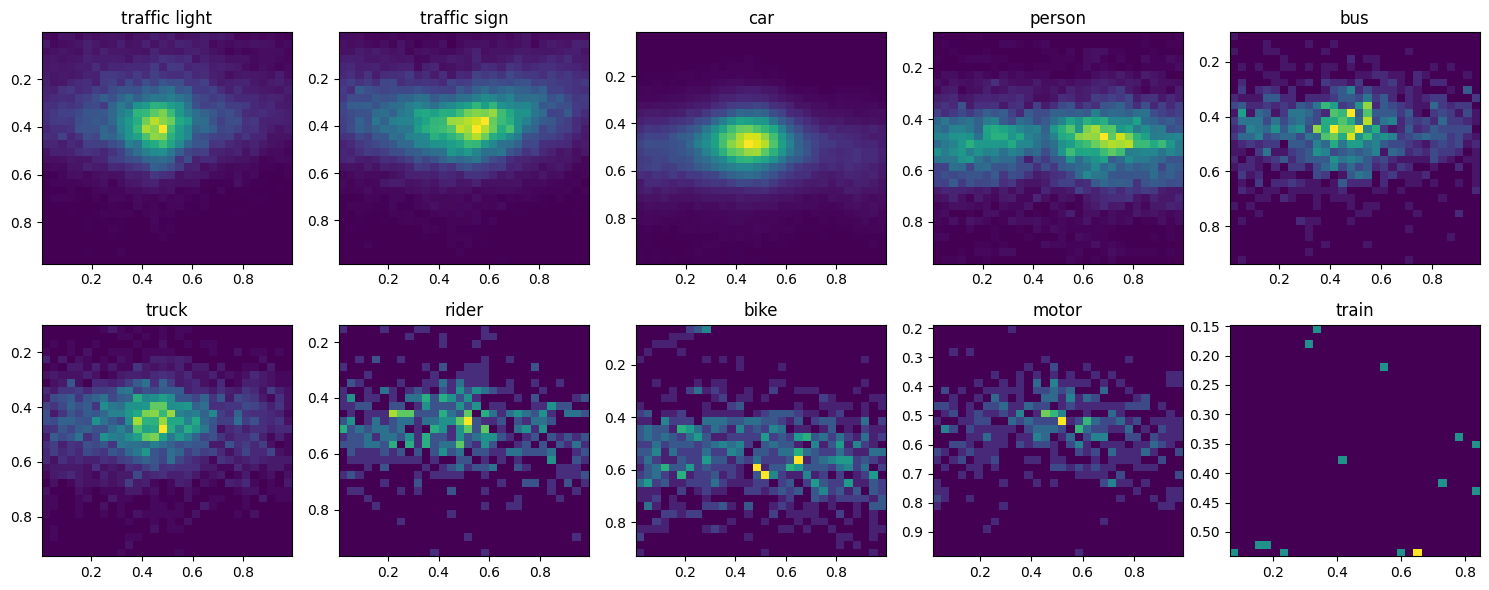

In [28]:

# compute centers
val_data.bbox_df["center_x"] = (val_data.bbox_df["x1"] + val_data.bbox_df["x2"]) / 2
val_data.bbox_df["center_y"] = (val_data.bbox_df["y1"] + val_data.bbox_df["y2"]) / 2

# normalize (since all images are 1280x720)
val_data.bbox_df["center_x"] /= 1280
val_data.bbox_df["center_y"] /= 720




fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 10 classes
axes = axes.flatten()

for i, cls in enumerate(classes):
    subset = val_data.bbox_df[val_data.bbox_df["category"] == cls]

    axes[i].hist2d(
        subset["center_x"],
        subset["center_y"],
        bins=30
    )

    axes[i].invert_yaxis()
    axes[i].set_title(cls)

plt.tight_layout()
plt.show()

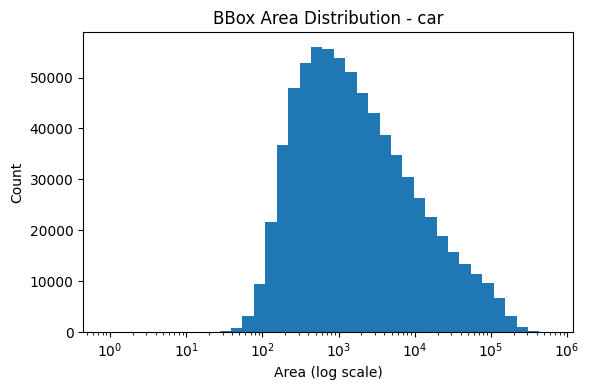

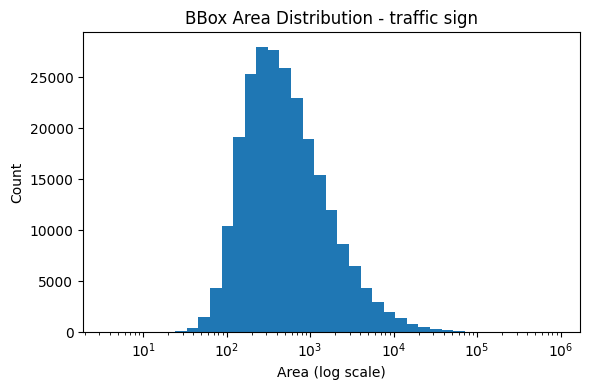

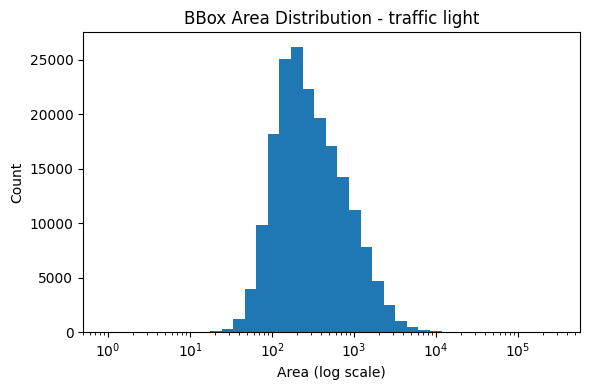

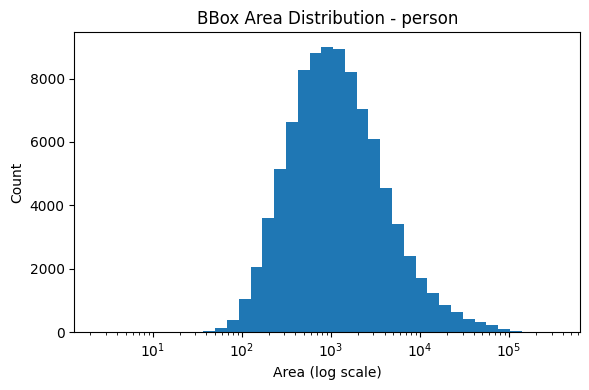

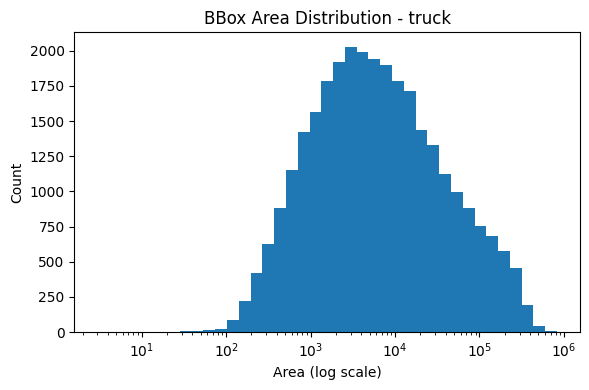

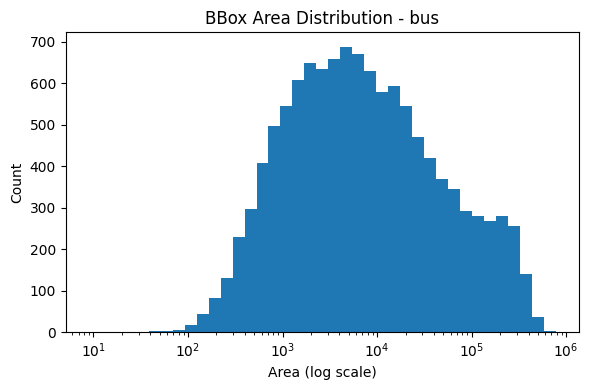

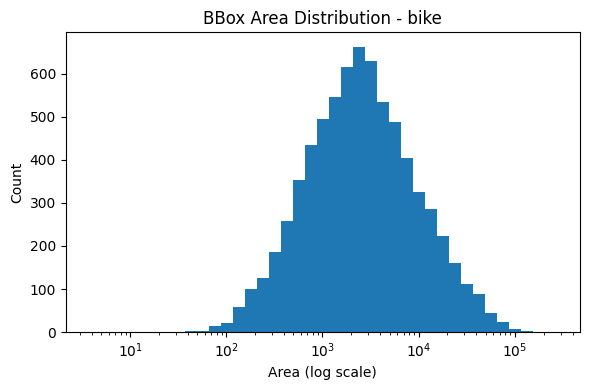

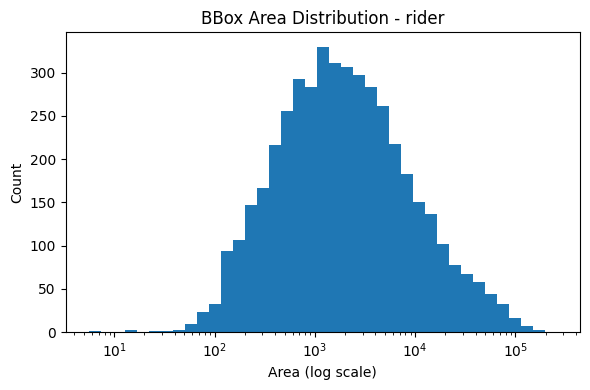

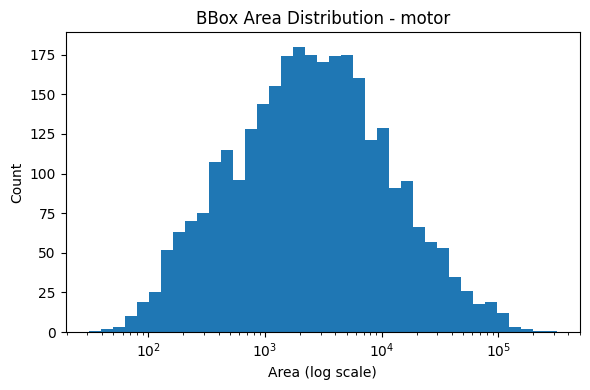

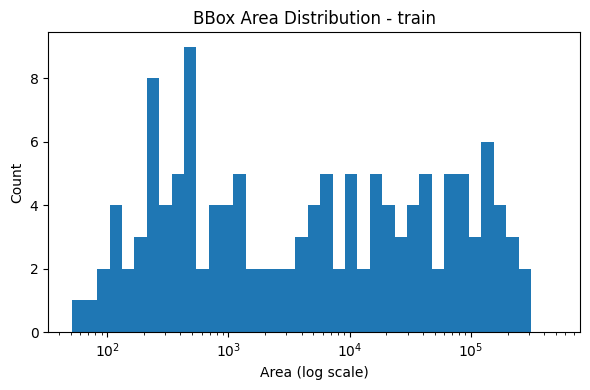

In [42]:
classes = train_data.bbox_df["category"].value_counts().index

for cls in classes:
    subset = train_data.bbox_df[train_data.bbox_df["category"] == cls]
    areas = subset['area']
    bins = np.logspace(np.log10(areas.min()), np.log10(areas.max()), 40)

    plt.figure(figsize=(6, 4))
    plt.hist(subset["area"], bins=bins)
    plt.xscale("log")

    plt.title(f"BBox Area Distribution - {cls}")
    plt.xlabel("Area (log scale)")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()